<a href="https://colab.research.google.com/github/Taran-Gupta/DS4002_Project2/blob/main/Scripts/Unemployment_and_Net_Worth_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Reading the files in.
unemployment = pd.read_csv("unemployment_cleaned.csv", index_col = 0)
net_worth = pd.read_csv("net_worth_cleaned.csv", index_col = 0)

In [3]:
# Combining them into one dataframe

unemployment.index = pd.to_datetime(unemployment.index)
net_worth.index = pd.to_datetime(net_worth.index)

combined = unemployment.join(net_worth, lsuffix = "unemp", rsuffix = "networth")

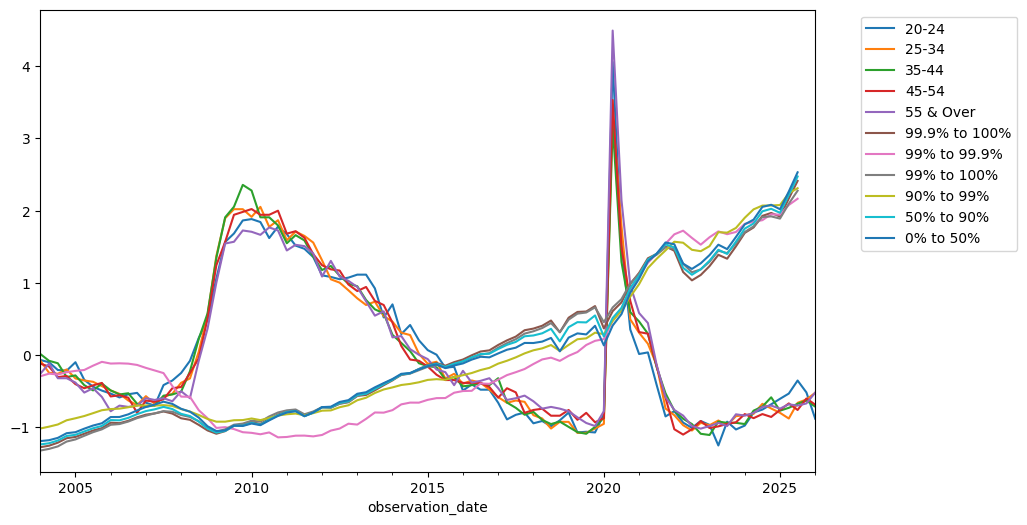

In [20]:
# Unemployment and net worth values are different, so it is best to normalize them before visualizing.

#Normalizing
normalized = (combined.select_dtypes(include = "number") - combined.select_dtypes(include = "number").mean()) / combined.select_dtypes(include = "number").std()
normalized.plot(figsize = (10,6))


plt.legend(loc = "upper left", bbox_to_anchor = (1.05, 1.0))

In [6]:
# Pearson correlation coefficient

#Creating correlation matrix for unemployment and net worth.

correlation_matrix = combined.select_dtypes(include = "number").corr(method='pearson')
print(correlation_matrix)

                  20-24     25-34     35-44     45-54  55 & Over  \
20-24          1.000000  0.983165  0.977490  0.981179   0.973886   
25-34          0.983165  1.000000  0.991733  0.992089   0.977905   
35-44          0.977490  0.991733  1.000000  0.990668   0.970394   
45-54          0.981179  0.992089  0.990668  1.000000   0.981768   
55 & Over      0.973886  0.977905  0.970394  0.981768   1.000000   
99.9% to 100% -0.452916 -0.454238 -0.457787 -0.443542  -0.357463   
99% to 99.9%  -0.555665 -0.559596 -0.557342 -0.562574  -0.485655   
99% to 100%   -0.444164 -0.445036 -0.449028 -0.434674  -0.348602   
90% to 99%    -0.460880 -0.462074 -0.462837 -0.459609  -0.381482   
50% to 90%    -0.456078 -0.458435 -0.461419 -0.450340  -0.366736   
0% to 50%     -0.457813 -0.461290 -0.463645 -0.456061  -0.375468   

               99.9% to 100%  99% to 99.9%  99% to 100%  90% to 99%  \
20-24              -0.452916     -0.555665    -0.444164   -0.460880   
25-34              -0.454238     -0.55959

In [22]:
correlation_matrix.loc[unemployment.columns, net_worth.columns]

,99.9% to 100%,99% to 99.9%,99% to 100%,90% to 99%,50% to 90%,0% to 50%
20-24,-0.452916,-0.555665,-0.444164,-0.460880,-0.456078,-0.457813
25-34,-0.454238,-0.559596,-0.445036,-0.462074,-0.458435,-0.461290
35-44,-0.457787,-0.557342,-0.449028,-0.462837,-0.461419,-0.463645
45-54,-0.443542,-0.562574,-0.434674,-0.459609,-0.450340,-0.456061
55 & Over,-0.357463,-0.485655,-0.348602,-0.381482,-0.366736,-0.375468


In [27]:
# Combining all unemployment and net worth by taking mean across groups.

unemp_series = unemployment.select_dtypes(include="number").mean(axis=1)

networth_series = net_worth.select_dtypes(include="number").mean(axis=1)

pearson_corr = unemp_series.corr(networth_series, method="pearson")
print(pearson_corr)  # Correlation coefficient is -.448. This is based on raw levels.

-0.448255872970768


In [10]:
#Combining the series for rolling correlation

combined_series = pd.concat([unemp_series, networth_series], axis=1).dropna()
combined_series.columns = ["unemp", "networth"]

In [25]:
# Taking percentage change for each column

combined_series["unemp_change"] = combined_series["unemp"].diff()
combined_series["networth_change"] = combined_series["networth"].pct_change()

# Doing pearson correlation again but measuring change.
pearson_corr_diff = unemp_series.diff().corr(networth_series.pct_change(), method="pearson")
print(pearson_corr_diff) # Correlation coefficient is .027.

0.02742252712134208


In [29]:
# Looking at top .1%

top1_networth = net_worth["99.9% to 100%"]

pearson_top1 = unemp_series.diff().corr(top1_networth.pct_change(), method="pearson")
print(pearson_top1) # Correlation coefficient is .046.

0.045845517371031125


In [26]:
# Rolling correlation with window of 2 years.

rolling_corr = combined_series["unemp_change"].rolling(8).corr(combined_series["networth_change"])

pd.set_option('display.max_rows', None) # display all rows
print(rolling_corr)

observation_date
2004-01-01         NaN
2004-04-01         NaN
2004-07-01         NaN
2004-10-01         NaN
2005-01-01         NaN
2005-04-01         NaN
2005-07-01         NaN
2005-10-01         NaN
2006-01-01   -0.168443
2006-04-01   -0.303963
2006-07-01   -0.374057
2006-10-01   -0.644728
2007-01-01   -0.622844
2007-04-01   -0.586271
2007-07-01   -0.475768
2007-10-01   -0.522871
2008-01-01   -0.492688
2008-04-01   -0.611238
2008-07-01   -0.746422
2008-10-01   -0.801665
2009-01-01   -0.642973
2009-04-01   -0.220981
2009-07-01   -0.241086
2009-10-01   -0.298553
2010-01-01   -0.542789
2010-04-01   -0.482614
2010-07-01   -0.572941
2010-10-01   -0.570270
2011-01-01   -0.064042
2011-04-01    0.039079
2011-07-01   -0.099070
2011-10-01   -0.111756
2012-01-01   -0.300021
2012-04-01   -0.323005
2012-07-01   -0.301920
2012-10-01   -0.548786
2013-01-01   -0.402568
2013-04-01   -0.394131
2013-07-01   -0.426225
2013-10-01   -0.460156
2014-01-01   -0.403485
2014-04-01   -0.097574
2014-07-01   -0.3

(array([ 0., 10., 20., 30., 40., 50., 60., 70., 80., 90.]),
 [Text(0.0, 0, '2004-01-01'),
  Text(10.0, 0, '2006-07-01'),
  Text(20.0, 0, '2009-01-01'),
  Text(30.0, 0, '2011-07-01'),
  Text(40.0, 0, '2014-01-01'),
  Text(50.0, 0, '2016-07-01'),
  Text(60.0, 0, '2019-01-01'),
  Text(70.0, 0, '2021-07-01'),
  Text(80.0, 0, '2024-01-01'),
  Text(90.0, 0, '')])

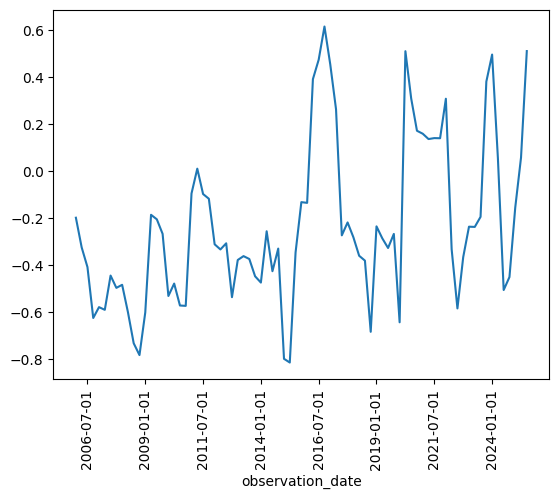

In [ ]:
rolling_corr.plot()
plt.xticks(rotation = 90)
plt.show()